# Process 1 – Sterilization Simulation Explorer

Use this notebook to inspect and correct the simulation output.
Re-run `generate_process_1.py` after tuning parameters in that file, then re-run this notebook.

In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import pm4py
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_vis

DATA_DIR = Path('..') / 'data' / 'gold' / 'experiment_1' / 'process_1' / 'datasets'

df_event_log      = pd.read_parquet(DATA_DIR / 'df_event_log.parquet')
df_expanded       = pd.read_parquet(DATA_DIR / 'df_expanded.parquet')
df_production_plan = pd.read_parquet(DATA_DIR / 'df_production_plan.parquet')

print('Event log:       ', df_event_log.shape)
print('Expanded:        ', df_expanded.shape)
print('Production plan: ', df_production_plan.shape)

Event log:        (7000, 8)
Expanded:         (35065, 17)
Production plan:  (500, 5)


## 1. Event log overview

In [19]:
print('Columns:', df_event_log.dtypes.to_dict())
df_event_log.head(14)

Columns: {'case_id': dtype('O'), 'activity': dtype('O'), 'timestamp_start': dtype('<M8[ns]'), 'timestamp_end': dtype('<M8[ns]'), 'higher_level_activity': dtype('O'), 'object_type': dtype('O'), 'object': dtype('O'), 'object_attributes': dtype('O')}


,case_id,activity,timestamp_start,timestamp_end,higher_level_activity,object_type,object,object_attributes
0,batch_001,Water_supply_prepare,2024-01-15 00:00:00.000000,2024-01-15 00:00:05.559925,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 463.3}"
1,batch_001,Water_supply_working,2024-01-15 00:00:06.559925,2024-01-15 00:01:13.906558,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 463.3}"
2,batch_001,Destillation_heat,2024-01-15 00:01:14.906558,2024-01-15 00:01:47.615250,Destillation,sterilization_line,destillation,"{'recipe': 'standard', 'volume_L': 463.3}"
3,batch_001,Bottling_prepare,2024-01-15 00:01:48.615250,2024-01-15 00:01:54.175175,Bottling,sterilization_line,bottling,"{'recipe': 'standard', 'volume_L': 463.3}"
4,batch_001,Bottling_working,2024-01-15 00:01:55.175175,2024-01-15 00:02:32.664783,Bottling,sterilization_line,bottling,"{'recipe': 'standard', 'volume_L': 463.3}"
5,batch_001,Bottling_cool,2024-01-15 00:02:33.664783,2024-01-15 00:02:39.224708,Bottling,sterilization_line,bottling,"{'recipe': 'standard', 'volume_L': 463.3}"
6,batch_001,Autoclaving_prepare,2024-01-15 00:02:40.224708,2024-01-15 00:04:40.184385,Autoclaving,sterilization_line,autoclaving,"{'recipe': 'standard', 'volume_L': 463.3}"
7,batch_001,Autoclaving_heat,2024-01-15 00:04:41.184385,2024-01-15 00:22:22.758636,Autoclaving,sterilization_line,autoclaving,"{'recipe': 'standard', 'volume_L': 463.3}"
8,batch_002,Water_supply_prepare,2024-01-15 00:15:00.000000,2024-01-15 00:15:02.859484,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 238.3}"
9,batch_002,Water_supply_working,2024-01-15 00:15:03.859484,2024-01-15 00:15:38.156163,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 238.3}"


In [20]:
# Activity counts per station
(
    df_event_log
    .groupby(['higher_level_activity', 'activity'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values(['higher_level_activity', 'activity'])
)

,higher_level_activity,activity,count
0,Autoclaving,Autoclaving_cool,500
1,Autoclaving,Autoclaving_heat,500
2,Autoclaving,Autoclaving_hold,500
3,Autoclaving,Autoclaving_prepare,500
4,Bottling,Bottling_cool,500
5,Bottling,Bottling_prepare,500
6,Bottling,Bottling_working,500
7,Destillation,Destillation_heat,500
8,Packaging,Packaging_prepare,500
9,Packaging,Packaging_working,500


## 2. pm4py Directly-Follows Graph (DFG)

### 2a. Activity-level DFG

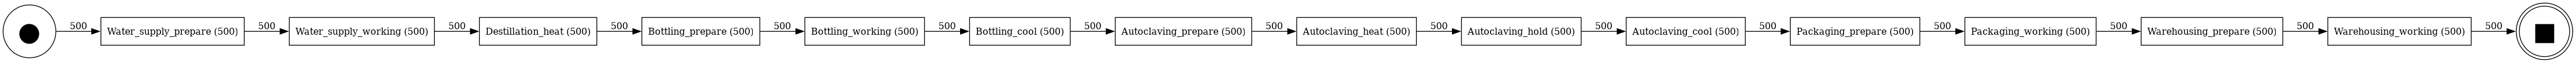

In [21]:
import tempfile
import pandas as pd
import pm4py
from IPython.display import Image, display
from pm4py.visualization.dfg import visualizer as dfg_vis

# Convert to pm4py event log format
el_pm4py = df_event_log.rename(columns={
    "case_id": "case:concept:name",
    "activity": "concept:name",
    "timestamp_start": "time:timestamp",
})

el_pm4py["time:timestamp"] = pd.to_datetime(el_pm4py["time:timestamp"])

log = pm4py.convert_to_event_log(el_pm4py)

dfg, start_acts, end_acts = pm4py.discover_dfg(log)

gviz = dfg_vis.apply(
    dfg,
    log=log,
    variant=dfg_vis.Variants.FREQUENCY,
    parameters={
        "start_activities": start_acts,
        "end_activities": end_acts
    }
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    dfg_vis.save(gviz, f.name)
    display(Image(filename=f.name))

### 2b. Station-level DFG  (higher_level_activity)

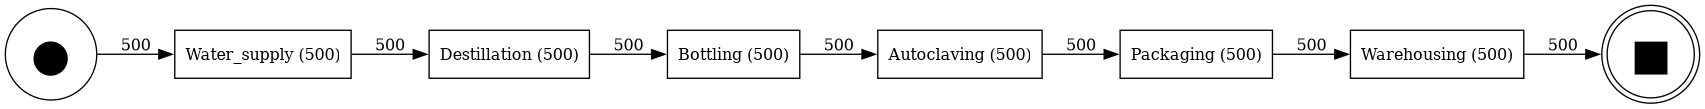

In [22]:
import tempfile
import pandas as pd
import pm4py
from IPython.display import Image, display
from pm4py.visualization.dfg import visualizer as dfg_vis

# Use first event per (case_id, station) as the station-level trace
station_log = (
    df_event_log
    .sort_values("timestamp_start")
    .groupby(["case_id", "higher_level_activity"], sort=False)
    .first()
    .reset_index()
    .rename(columns={
        "case_id": "case:concept:name",
        "higher_level_activity": "concept:name",
        "timestamp_start": "time:timestamp",
    })
)

station_log["time:timestamp"] = pd.to_datetime(station_log["time:timestamp"])

log_station = pm4py.convert_to_event_log(station_log)

dfg_s, sa_s, ea_s = pm4py.discover_dfg(log_station)

gviz_s = dfg_vis.apply(
    dfg_s,
    log=log_station,
    variant=dfg_vis.Variants.FREQUENCY,
    parameters={
        "start_activities": sa_s,
        "end_activities": ea_s
    }
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    dfg_vis.save(gviz_s, f.name)
    display(Image(filename=f.name))

## 3. Process model – Inductive Miner (Petri net)

Petri nets discovered with the **Inductive Miner** give you a formal model of the control flow. A green square = source place (start), a red square = sink place (end), rounded boxes = transitions (activities).

### 3a. Activity-level Petri net

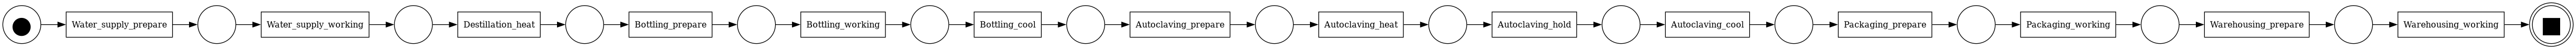

In [23]:
import tempfile
from IPython.display import Image, display
from pm4py.visualization.petri_net import visualizer as pn_vis

# Discover Petri net from the activity-level log
net_a, im_a, fm_a = pm4py.discover_petri_net_inductive(log)

gviz_pn_a = pn_vis.apply(
    net_a,
    im_a,
    fm_a,
    variant=pn_vis.Variants.FREQUENCY,
    parameters={"log": log}
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    pn_vis.save(gviz_pn_a, f.name)
    display(Image(filename=f.name))

### 3b. Station-level Petri net

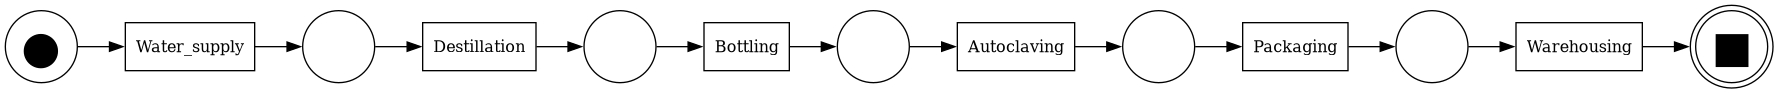

In [24]:
import tempfile
from IPython.display import Image, display
from pm4py.visualization.petri_net import visualizer as pn_vis

# Discover Petri net from the station-level log
net_s, im_s, fm_s = pm4py.discover_petri_net_inductive(log_station)

gviz_pn_s = pn_vis.apply(
    net_s,
    im_s,
    fm_s,
    variant=pn_vis.Variants.FREQUENCY,
    parameters={"log": log_station}
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    pn_vis.save(gviz_pn_s, f.name)
    display(Image(filename=f.name))

## 3. Duration distributions per station / activity

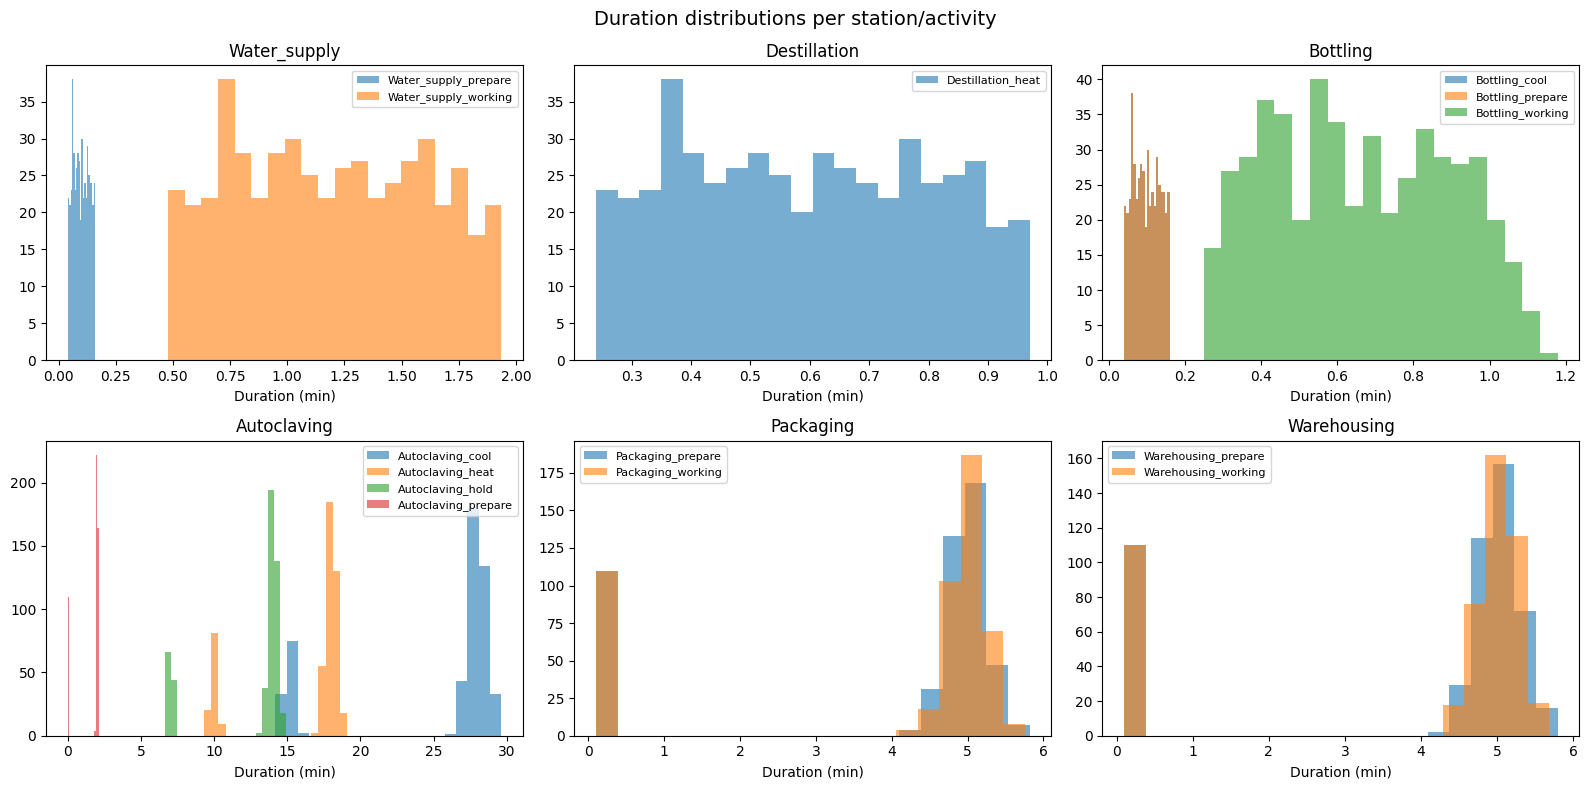

In [25]:
df_event_log['duration_min'] = (
    (df_event_log['timestamp_end'] - df_event_log['timestamp_start'])
    .dt.total_seconds() / 60
)

stations = df_event_log['higher_level_activity'].unique()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, station in zip(axes, stations):
    sub = df_event_log[df_event_log['higher_level_activity'] == station]
    for act, grp in sub.groupby('activity'):
        ax.hist(grp['duration_min'], bins=20, alpha=0.6, label=act)
    ax.set_title(station)
    ax.set_xlabel('Duration (min)')
    ax.legend(fontsize=8)

plt.suptitle('Duration distributions per station/activity', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Gantt chart – batch timeline (first 20 batches)

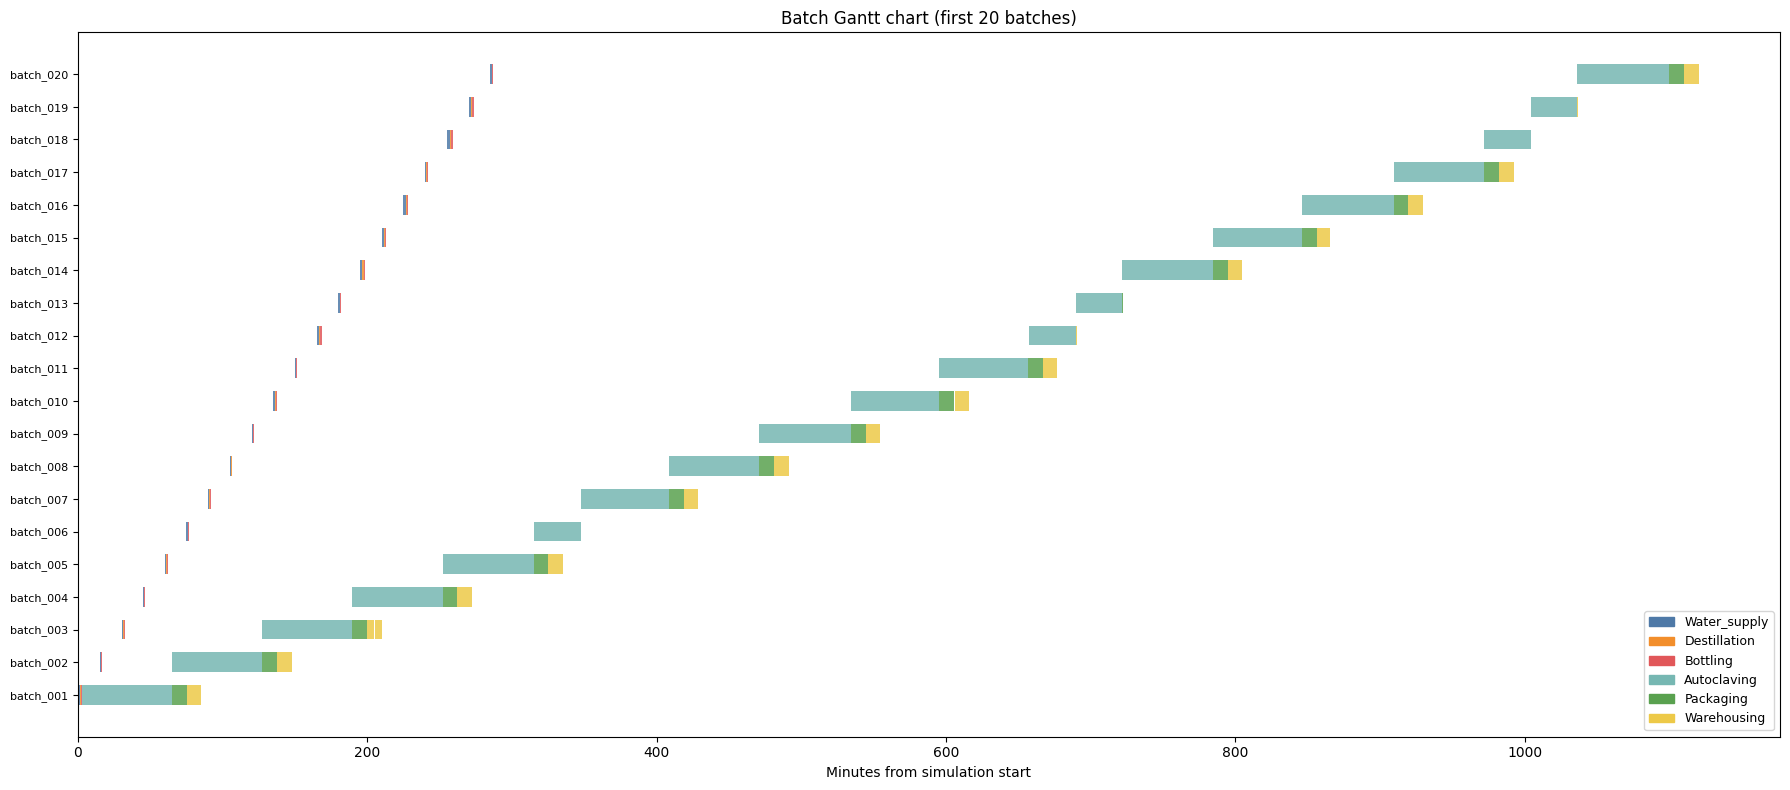

In [26]:
N_GANTT = 20
batches = df_event_log['case_id'].unique()[:N_GANTT]

STATION_COLORS = {
    'Water_supply':  '#4e79a7',
    'Destillation':  '#f28e2b',
    'Bottling':      '#e15759',
    'Autoclaving':   '#76b7b2',
    'Packaging':     '#59a14f',
    'Warehousing':   '#edc948',
}

fig, ax = plt.subplots(figsize=(18, 8))
t0 = df_event_log['timestamp_start'].min()

for yi, bid in enumerate(batches):
    sub = df_event_log[df_event_log['case_id'] == bid]
    for _, row in sub.iterrows():
        start = (row['timestamp_start'] - t0).total_seconds() / 60
        dur   = (row['timestamp_end']   - row['timestamp_start']).total_seconds() / 60
        color = STATION_COLORS.get(row['higher_level_activity'], 'grey')
        ax.barh(yi, dur, left=start, height=0.6, color=color, alpha=0.85)

ax.set_yticks(range(N_GANTT))
ax.set_yticklabels(batches, fontsize=8)
ax.set_xlabel('Minutes from simulation start')
ax.set_title('Batch Gantt chart (first 20 batches)')
patches = [mpatches.Patch(color=c, label=s) for s, c in STATION_COLORS.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Energy curves – sample batches

Each subplot shows one energy sensor over time, colored by activity.

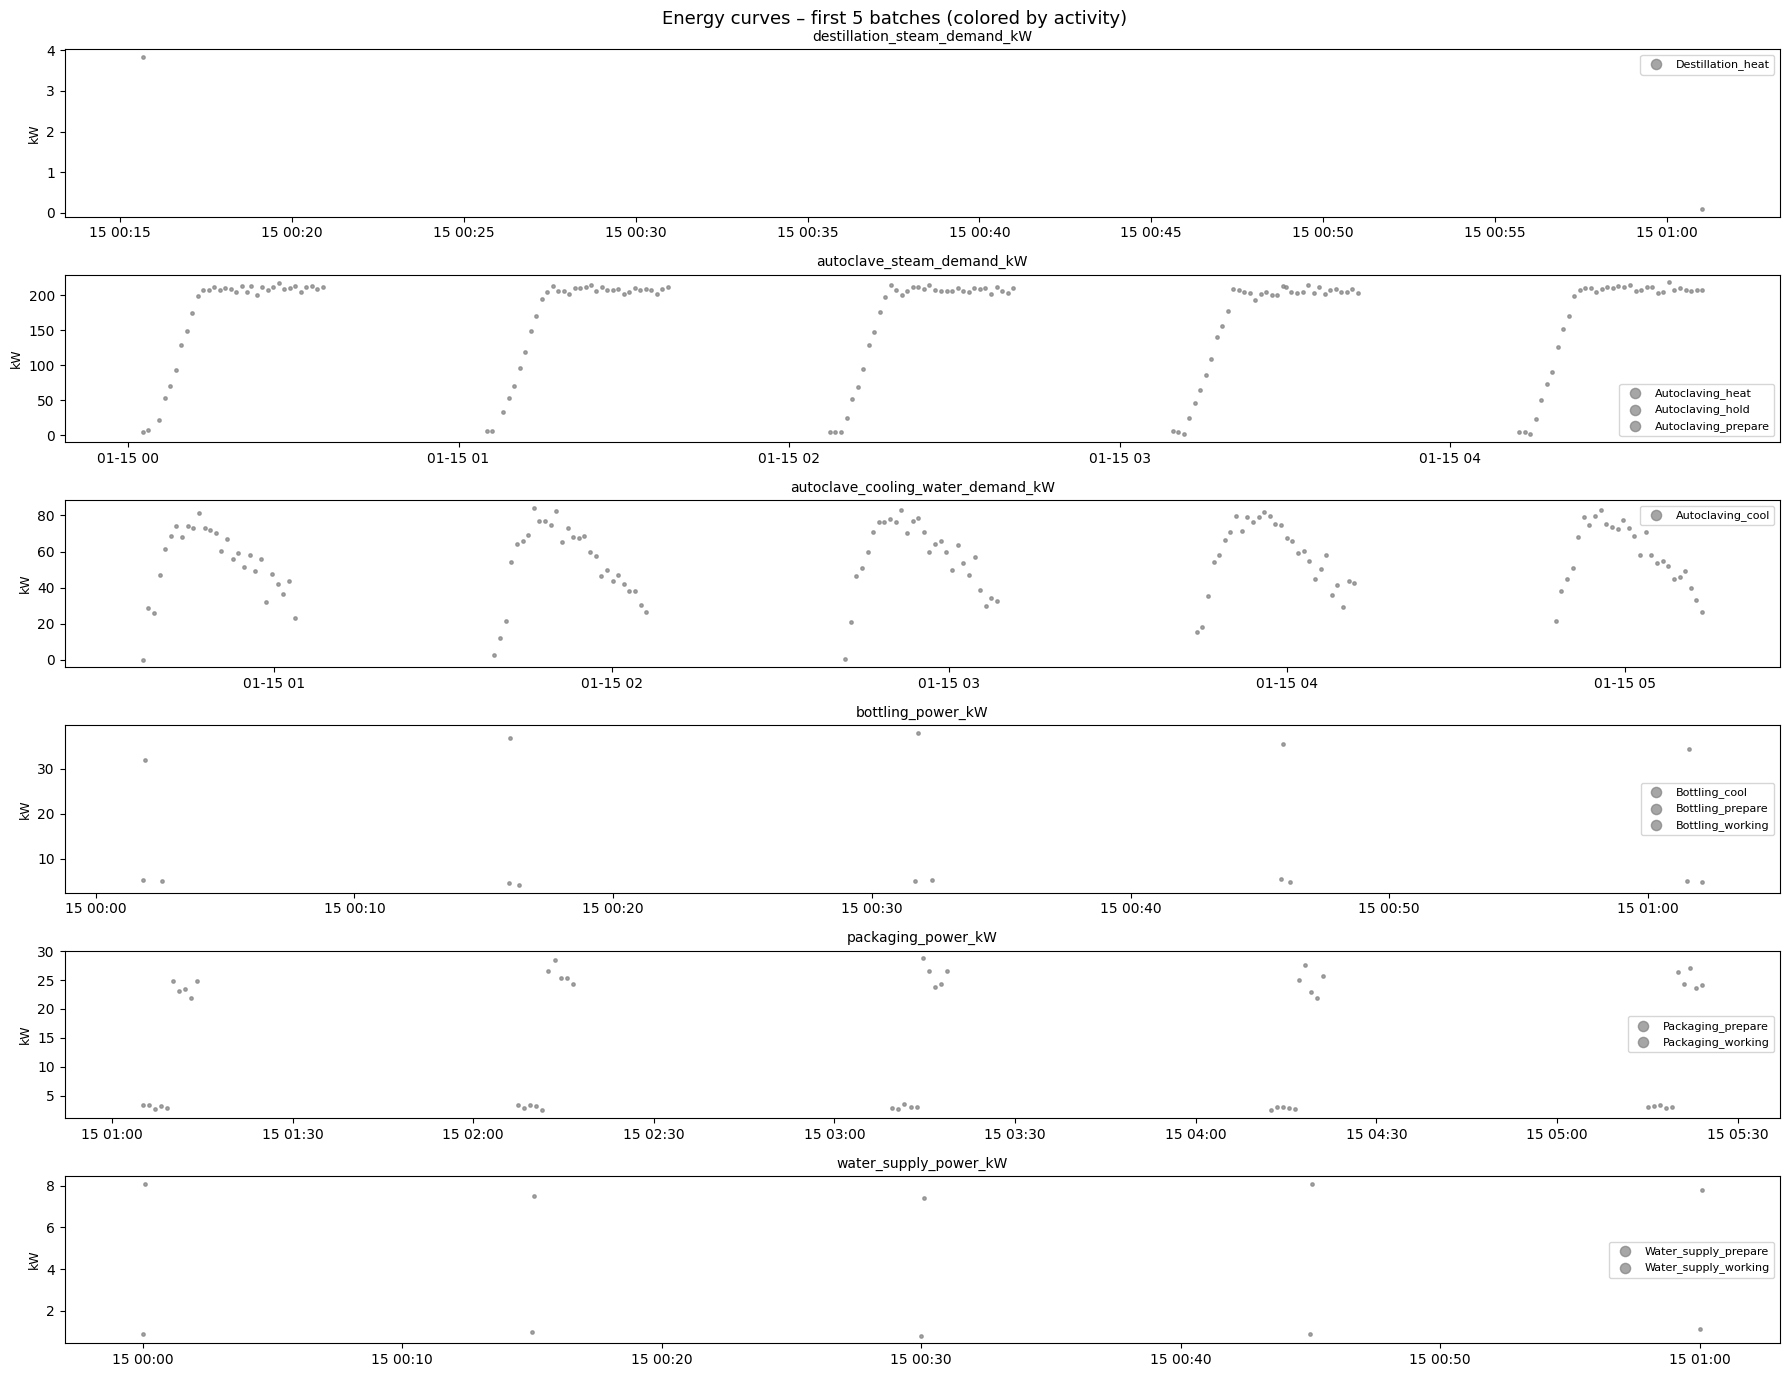

In [27]:
ENERGY_SENSORS = [
    'destillation_steam_demand_kW_energy',
    'autoclave_steam_demand_kW_energy',
    'autoclave_cooling_water_demand_kW_energy',
    'bottling_power_kW_energy',
    'packaging_power_kW_energy',
    'water_supply_power_kW_energy',
]

ACTIVITY_COLORS = {
    'prepare': '#4e79a7',
    'heat':    '#f28e2b',
    'hold':    '#e15759',
    'cool':    '#76b7b2',
    'working': '#59a14f',
}

# Show first 5 batches for clarity
SAMPLE_BATCHES = df_event_log['case_id'].unique()[:5]
sub_exp = df_expanded[df_expanded['case_id_log'].isin(SAMPLE_BATCHES)].copy()

fig, axes = plt.subplots(len(ENERGY_SENSORS), 1, figsize=(18, 14), sharex=False)

for ax, sensor in zip(axes, ENERGY_SENSORS):
    active = sub_exp[sub_exp[sensor] > 0].copy()
    if active.empty:
        ax.set_title(sensor + ' — no data')
        continue
    for act, grp in active.groupby('activity_log'):
        color = ACTIVITY_COLORS.get(act, 'grey')
        ax.scatter(grp['datetime_energy'], grp[sensor],
                   s=6, color=color, alpha=0.7, label=act)
    ax.set_ylabel('kW', fontsize=9)
    ax.set_title(sensor.replace('_energy', ''), fontsize=10)
    ax.legend(fontsize=8, markerscale=3)

plt.suptitle('Energy curves – first 5 batches (colored by activity)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Weather vs. energy – verifying physical relationships

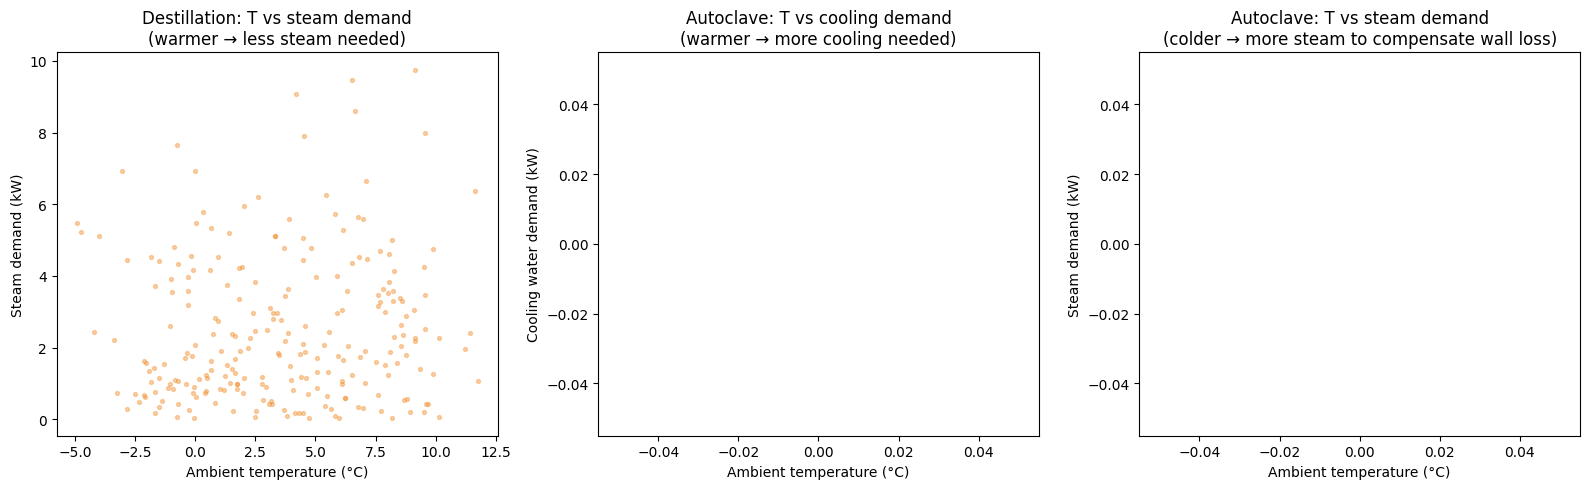

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 6a. Temperature vs. distillation steam demand
dest = df_expanded[df_expanded['destillation_steam_demand_kW_energy'] > 0]
axes[0].scatter(dest['ef_temperature_2m_energy'],
                dest['destillation_steam_demand_kW_energy'],
                s=8, alpha=0.4, color='#f28e2b')
axes[0].set_xlabel('Ambient temperature (°C)')
axes[0].set_ylabel('Steam demand (kW)')
axes[0].set_title('Destillation: T vs steam demand\n(warmer → less steam needed)')

# 6b. Temperature vs. autoclave cooling water demand (cool phase only)
cool = df_expanded[
    (df_expanded['autoclave_cooling_water_demand_kW_energy'] > 0) &
    (df_expanded['activity_log'] == 'cool')
]
axes[1].scatter(cool['ef_temperature_2m_energy'],
                cool['autoclave_cooling_water_demand_kW_energy'],
                s=8, alpha=0.4, color='#76b7b2')
axes[1].set_xlabel('Ambient temperature (°C)')
axes[1].set_ylabel('Cooling water demand (kW)')
axes[1].set_title('Autoclave: T vs cooling demand\n(warmer → more cooling needed)')

# 6c. Temperature vs. autoclave steam demand (heat + hold)
steam = df_expanded[
    (df_expanded['autoclave_steam_demand_kW_energy'] > 0) &
    (df_expanded['activity_log'].isin(['heat', 'hold']))
]
axes[2].scatter(steam['ef_temperature_2m_energy'],
                steam['autoclave_steam_demand_kW_energy'],
                s=8, alpha=0.4, color='#e15759')
axes[2].set_xlabel('Ambient temperature (°C)')
axes[2].set_ylabel('Steam demand (kW)')
axes[2].set_title('Autoclave: T vs steam demand\n(colder → more steam to compensate wall loss)')

plt.tight_layout()
plt.show()

## 7. Weather time series over the simulation period

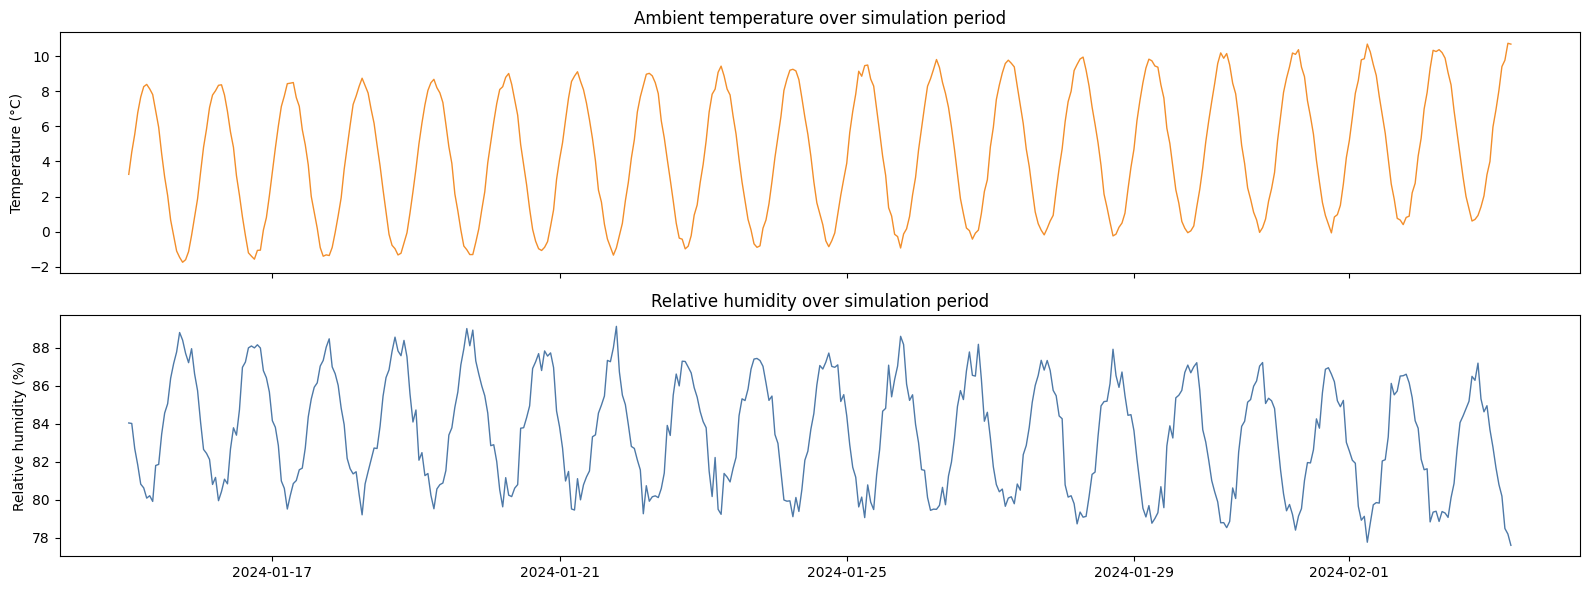

In [29]:
weather = (
    df_expanded
    .set_index('datetime_energy')[['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy']]
    .resample('1h').mean()
    .dropna()
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

ax1.plot(weather.index, weather['ef_temperature_2m_energy'], color='#f28e2b', lw=1)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Ambient temperature over simulation period')

ax2.plot(weather.index, weather['ef_relative_humidity_2m_energy'], color='#4e79a7', lw=1)
ax2.set_ylabel('Relative humidity (%)')
ax2.set_title('Relative humidity over simulation period')

plt.tight_layout()
plt.show()

## 8. Autoclave load – how many autoclave resources run in parallel

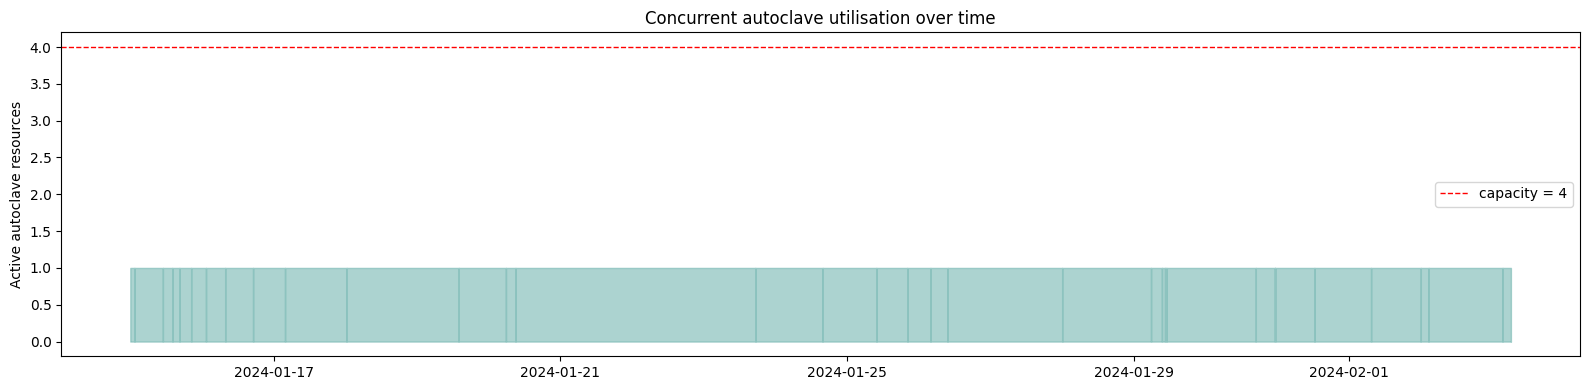

In [30]:
ac_events = df_event_log[df_event_log['higher_level_activity'] == 'Autoclaving'].copy()

# Build 1-minute timeline of concurrent autoclave usage
t_min = ac_events['timestamp_start'].min().floor('min')
t_max = ac_events['timestamp_end'].max().ceil('min')
timeline = pd.date_range(t_min, t_max, freq='min')

concurrent = np.zeros(len(timeline))
for _, row in ac_events.iterrows():
    mask = (timeline >= row['timestamp_start']) & (timeline < row['timestamp_end'])
    concurrent[mask] += 1

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(timeline, concurrent, step='pre', alpha=0.6, color='#76b7b2')
ax.set_ylabel('Active autoclave resources')
ax.set_title('Concurrent autoclave utilisation over time')
ax.axhline(4, color='red', linestyle='--', lw=1, label='capacity = 4')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Expanded dataset overview

In [31]:
df_expanded.head(5)

,datetime_energy,ef_temperature_2m_energy,ef_relative_humidity_2m_energy,destillation_steam_demand_kW_energy,autoclave_steam_demand_kW_energy,autoclave_cooling_water_demand_kW_energy,bottling_power_kW_energy,packaging_power_kW_energy,water_supply_power_kW_energy,timestamp_start_log,timestamp_end_log,activity_log,higher_level_activity_log,object_type_log,object_log,case_id_log,object_attributes_log
0,2024-01-15 00:00:00.000000,1.941789,75.487378,0.0,0.0,0.0,0.000000,0.0,0.882894,2024-01-15 00:00:00.000000,2024-01-15 00:00:05.559925,Water_supply_prepare,Water_supply,sterilization_line,water_supply,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
1,2024-01-15 00:00:06.559925,2.129406,91.428965,0.0,0.0,0.0,0.000000,0.0,8.102866,2024-01-15 00:00:06.559925,2024-01-15 00:01:13.906558,Water_supply_working,Water_supply,sterilization_line,water_supply,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
2,2024-01-15 00:01:14.906558,2.769762,80.791063,0.0,0.0,0.0,0.000000,0.0,0.000000,2024-01-15 00:01:14.906558,2024-01-15 00:01:47.615250,Destillation_heat,Destillation,sterilization_line,destillation,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
3,2024-01-15 00:01:48.615250,2.765596,83.017738,0.0,0.0,0.0,5.292771,0.0,0.000000,2024-01-15 00:01:48.615250,2024-01-15 00:01:54.175175,Bottling_prepare,Bottling,sterilization_line,bottling,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
4,2024-01-15 00:01:55.175175,3.854121,73.527360,0.0,0.0,0.0,31.864168,0.0,0.000000,2024-01-15 00:01:55.175175,2024-01-15 00:02:32.664783,Bottling_working,Bottling,sterilization_line,bottling,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"


In [32]:
# Summary stats for energy sensors
sensors = [
    'destillation_steam_demand_kW_energy',
    'autoclave_steam_demand_kW_energy',
    'autoclave_cooling_water_demand_kW_energy',
    'bottling_power_kW_energy',
    'packaging_power_kW_energy',
    'water_supply_power_kW_energy',
]
# Only non-zero rows per sensor
summary = {}
for s in sensors:
    d = df_expanded[df_expanded[s] > 0][s]
    summary[s] = {'n_rows': len(d), 'mean': d.mean(), 'std': d.std(),
                  'min': d.min(), 'max': d.max()}
pd.DataFrame(summary).T.round(2)

,n_rows,mean,std,min,max
destillation_steam_demand_kW_energy,240.0,2.48,2.02,0.03,9.76
autoclave_steam_demand_kW_energy,14990.0,169.88,68.40,0.01,224.56
autoclave_cooling_water_demand_kW_energy,12335.0,56.72,19.23,0.01,99.47
bottling_power_kW_energy,1500.0,14.97,14.17,3.40,40.62
packaging_power_kW_energy,4116.0,14.02,11.08,2.11,30.31
water_supply_power_kW_energy,1140.0,4.93,3.49,0.48,9.35


# 10. Conformance Diagnosis — Petri net approaches (no energy models)

Train/test split → mine Petri net from train → simulate on test → compute the exact same
conformance metrics as `modelling.py` to diagnose why precision = 0 for process_1.

## Metric guide

### Conformance metrics (all 0–1, higher = better)

| Metric | What it measures | How to read it |
|--------|-----------------|----------------|
| **Fitness** | Can every event in the log be replayed by the Petri net without token errors? | 1.0 = all traces follow the model exactly. <0.8 = model is missing real behaviour (the log does things the net can't explain). |
| **Precision** | Does the model over-allow behaviour that never appears in the log? | 1.0 = model permits only what is observed. 0.4 = at each step, the net enables ~2.5× more transitions than actually fire — the model is too permissive (a "spaghetti" net that accepts almost anything). |
| **Generalization** | Is the model overfitted to the training traces? | ~0.9 = good. Penalises transitions that are rarely exercised relative to their maximum possible use. |
| **Simplicity** | Structural complexity of the Petri net. | 1/(1 + 0.005 × (places + transitions + arcs)). A 4-step sequential net scores ~0.92; complex loop nets score lower. |

### Additional process simulation metrics

| Metric | What it measures | Ideal |
|--------|-----------------|-------|
| **Event ratio** | `len(sim_log) / len(real_log)` — does the simulation produce the right number of events? | 1.0. >1 = sim generates more events than reality; <1 = fewer. |
| **Mean/Med duration error** | Relative error in activity durations between sim and real (`|sim_mean - real_mean| / real_mean`). | 0.0 (= no timing error). |

---

### Why precision = 0.4 in the heatmap (known diagnostic artefact)

`extract_process` mines **one Petri net per resource object** (e.g. `autoclaving_1`, `autoclaving_2`, …). The diagnostic loop below collects only the **first net** found for `sterilization_line` (= the `autoclaving_1` net, 4 transitions: prepare→heat→hold→cool). It then evaluates that net against the **full 14-activity cross-station log**.

pm4py token-based precision: at every point where the autoclaving net has a transition enabled (which it does from the very first token), it counts whether a net transition was fired. For the 10 non-autoclaving activities per trace, the net has 1 transition enabled but fires 0 → precision ≈ 4 fired / ~10 enabled ≈ **0.4**.

**Evaluated correctly** (station log vs station net): precision = **1.0** for every station and algorithm. This is the value that matters.

---

### Why event ratio = 2.14 in test (known structural limitation)

The `ProcessSimulation` runs each production-plan batch through **every resource object** that has a Petri net — including all 4 autoclaves, both packaging lines, and both warehousing units. So each batch generates:
- autoclave_1 + autoclave_2 + autoclave_3 + autoclave_4: **16 events** (4 × prepare/heat/hold/cool)
- bottling + destillation + packaging_1 + packaging_2 + warehousing_1 + warehousing_2 + water_supply: **14 events**
- **Total: 30 events/batch** in simulation

In reality each batch passes through **one autoclave only** → 14 events/batch. So ratio = 30/14 ≈ **2.14**. This is a modelling artefact, not a process problem.

In [33]:
import sys
sys.path.insert(0, str(Path('.').resolve()))

from sim_extractor import extract_process
from simulation import ProcessSimulation
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay

try:
    from pm4py.algo.evaluation.generalization import algorithm as _pm4py_gen
except Exception:
    _pm4py_gen = None

try:
    from pm4py.algo.evaluation.simplicity import algorithm as _pm4py_sim
except Exception:
    _pm4py_sim = None

def _fitness(log_pm4py, net, im, fm):
    try:
        replay = token_replay.apply(log_pm4py, net, im, fm,
                                    parameters={'consider_remaining_in_fitness': True})
        scores = [float(r['trace_fitness']) for r in replay
                  if 'trace_fitness' in r and r['trace_fitness'] is not None]
        return float(np.mean(scores)) if scores else np.nan
    except Exception:
        return np.nan

def _precision(log_pm4py, net, im, fm):
    try:
        return float(pm4py.precision_token_based_replay(log_pm4py, net, im, fm))
    except Exception as e:
        print(f"  precision error: {e}")
        return np.nan

def _generalization(log_pm4py, net, im, fm):
    if _pm4py_gen is None:
        return np.nan
    try:
        return float(_pm4py_gen.apply(log_pm4py, net, im, fm))
    except Exception:
        return np.nan

def _simplicity(net):
    if _pm4py_sim is not None:
        try:
            return float(_pm4py_sim.apply(net))
        except Exception:
            pass
    complexity = len(net.places) + len(net.transitions) + len(net.arcs)
    return float(1.0 / (1.0 + 0.005 * float(complexity)))

def to_pm4py_log(df):
    el = df.rename(columns={
        'case_id': 'case:concept:name',
        'activity': 'concept:name',
        'timestamp_start': 'time:timestamp',
    })[['case:concept:name', 'concept:name', 'time:timestamp']].copy()
    el['time:timestamp'] = pd.to_datetime(el['time:timestamp'])
    return pm4py.convert_to_event_log(el)

# 50/50 temporal split
_all_cases = (df_event_log.sort_values('timestamp_start')
                           .groupby('case_id')['timestamp_start'].min()
                           .sort_values().index.tolist())
_n_train    = max(1, len(_all_cases) // 2)
_train_cases = set(_all_cases[:_n_train])
_test_cases  = set(_all_cases[_n_train:])

df_train = df_event_log[df_event_log['case_id'].isin(_train_cases)].copy()
df_test  = df_event_log[df_event_log['case_id'].isin(_test_cases)].copy()

print(f"Train: {len(_train_cases)} cases / {len(df_train)} events")
print(f"Test:  {len(_test_cases)} cases  / {len(df_test)} events")

Train: 250 cases / 3500 events
Test:  250 cases  / 3500 events



  ALGORITHM: INDUCTIVE

Processing: autoclaving (sterilization_line) - Autoclaving
  Mining algorithm: inductive
  Found 4 unique activities: ['Autoclaving_prepare' 'Autoclaving_heat' 'Autoclaving_hold'
 'Autoclaving_cool']
    Autoclaving_prepare: best fit = norm (1.998676705638474, 0.039622277726927856)
    Autoclaving_heat: best fit = weibull_min (8.508917704463343, 0.0, 17.589882003885933)
    Autoclaving_hold: best fit = weibull_min (7.270323678472697, 0.0, 13.612509314839542)
    Autoclaving_cool: best fit = weibull_min (8.063219497778288, 0.0, 27.276186709011345)
    Mining Petri net with 'inductive' (candidate 1/1): noise=0.2, heur={}


replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9842, fitness=1.0000, precision=1.0000, generalization=0.9367544467966324, simplicity=1.0
    Selected params: noise=0.2, heur={} (score=0.9842)
    Petri net: 5 places, 4 transitions, 8 arcs
    Stochastic map: 4 transition weights
    Decision-point weights: 4 decision points, 0 with __END__ probability
    Max case length in training: 4
      Autoclaving_prepare: Start=True, End=False, Transitions={'Autoclaving_heat': 1.0}
      Autoclaving_heat: Start=False, End=False, Transitions={'Autoclaving_hold': 1.0}
      Autoclaving_hold: Start=False, End=False, Transitions={'Autoclaving_cool': 1.0}
      Autoclaving_cool: Start=False, End=True, Transitions={'__END__': 1.0}
    History weights: 4 bigram keys, 4 activity-count keys

Processing: bottling (sterilization_line) - Bottling
  Mining algorithm: inductive
  Found 3 unique activities: ['Bottling_prepare' 'Bottling_working' 'Bottling_cool']
    Bottling_prepare: best fit = weibull_min (3.297853069533603, 0.0, 0.

replaying log with TBR, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]

      quality: score=0.9842, fitness=1.0000, precision=1.0000, generalization=0.9367544467966324, simplicity=1.0
    Selected params: noise=0.2, heur={} (score=0.9842)
    Petri net: 4 places, 3 transitions, 6 arcs
    Stochastic map: 3 transition weights
    Decision-point weights: 3 decision points, 0 with __END__ probability
    Max case length in training: 3
      Bottling_prepare: Start=True, End=False, Transitions={'Bottling_working': 1.0}
      Bottling_working: Start=False, End=False, Transitions={'Bottling_cool': 1.0}
      Bottling_cool: Start=False, End=True, Transitions={'__END__': 1.0}
    History weights: 3 bigram keys, 3 activity-count keys

Processing: destillation (sterilization_line) - Destillation
  Mining algorithm: inductive
  Found 1 unique activities: ['Destillation_heat']
    Destillation_heat: best fit = weibull_min (3.2903830188083383, 0.0, 0.663379508518636)
    Mining Petri net with 'inductive' (candidate 1/1): noise=0.2, heur={}
      quality: score=0.9842,

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]


  Per-station conformance (6 stations):
    TRAIN  fitness=1.0000  precision=1.0000  generalization=0.9368  simplicity=1.0000
    TEST   fitness=1.0000  precision=1.0000  generalization=0.9368  simplicity=1.0000
[DEBUG __init__] mode=petri_net, process_models is None: False, process_models len: 6
Building config from 14 activities:
  Config: ('Autoclaving_prepare', 'autoclaving', 'sterilization_line', 'Autoclaving')
    Transitions: {'Autoclaving_heat': 1.0}
    Start: True
  Config: ('Autoclaving_heat', 'autoclaving', 'sterilization_line', 'Autoclaving')
    Transitions: {'Autoclaving_hold': 1.0}
    Start: False
  Config: ('Autoclaving_hold', 'autoclaving', 'sterilization_line', 'Autoclaving')
    Transitions: {'Autoclaving_cool': 1.0}
    Start: False
  Config: ('Autoclaving_cool', 'autoclaving', 'sterilization_line', 'Autoclaving')
    Transitions: {'__END__': 1.0}
    Start: False
  Config: ('Bottling_prepare', 'bottling', 'sterilization_line', 'Bottling')
    Transitions: {'Bott

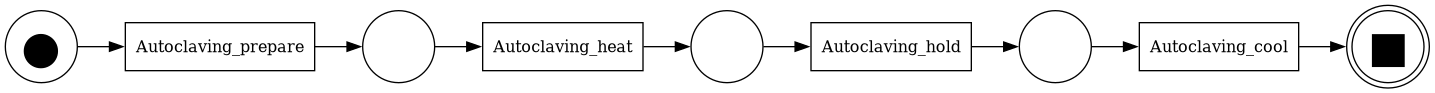


  ALGORITHM: HEURISTIC

Processing: autoclaving (sterilization_line) - Autoclaving
  Mining algorithm: heuristic
  Found 4 unique activities: ['Autoclaving_prepare' 'Autoclaving_heat' 'Autoclaving_hold'
 'Autoclaving_cool']
    Autoclaving_prepare: best fit = norm (1.998676705638474, 0.039622277726927856)
    Autoclaving_heat: best fit = weibull_min (8.508917704463343, 0.0, 17.589882003885933)
    Autoclaving_hold: best fit = weibull_min (7.270323678472697, 0.0, 13.612509314839542)
    Autoclaving_cool: best fit = weibull_min (8.063219497778288, 0.0, 27.276186709011345)
    Mining Petri net with 'heuristic' (candidate 1/1): noise=0.2, heur={}


replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9842, fitness=1.0000, precision=1.0000, generalization=0.9367544467966324, simplicity=1.0
    Selected params: noise=0.2, heur={} (score=0.9842)
    Petri net: 5 places, 4 transitions, 8 arcs
    Stochastic map: 4 transition weights
    Decision-point weights: 4 decision points, 0 with __END__ probability
    Max case length in training: 4
      Autoclaving_prepare: Start=True, End=False, Transitions={'Autoclaving_heat': 1.0}
      Autoclaving_heat: Start=False, End=False, Transitions={'Autoclaving_hold': 1.0}
      Autoclaving_hold: Start=False, End=False, Transitions={'Autoclaving_cool': 1.0}
      Autoclaving_cool: Start=False, End=True, Transitions={'__END__': 1.0}
    History weights: 4 bigram keys, 4 activity-count keys

Processing: bottling (sterilization_line) - Bottling
  Mining algorithm: heuristic
  Found 3 unique activities: ['Bottling_prepare' 'Bottling_working' 'Bottling_cool']
    Bottling_prepare: best fit = weibull_min (3.297853069533603, 0.0, 0.

replaying log with TBR, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]

      quality: score=0.9842, fitness=1.0000, precision=1.0000, generalization=0.9367544467966324, simplicity=1.0
    Selected params: noise=0.2, heur={} (score=0.9842)
    Petri net: 4 places, 3 transitions, 6 arcs
    Stochastic map: 3 transition weights
    Decision-point weights: 3 decision points, 0 with __END__ probability
    Max case length in training: 3
      Bottling_prepare: Start=True, End=False, Transitions={'Bottling_working': 1.0}
      Bottling_working: Start=False, End=False, Transitions={'Bottling_cool': 1.0}
      Bottling_cool: Start=False, End=True, Transitions={'__END__': 1.0}
    History weights: 3 bigram keys, 3 activity-count keys

Processing: destillation (sterilization_line) - Destillation
  Mining algorithm: heuristic
  Found 1 unique activities: ['Destillation_heat']
    Destillation_heat: best fit = weibull_min (3.2903830188083383, 0.0, 0.663379508518636)
    Mining Petri net with 'heuristic' (candidate 1/1): noise=0.2, heur={}
      quality: score=0.9842,

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]


  Per-station conformance (6 stations):
    TRAIN  fitness=1.0000  precision=1.0000  generalization=0.9368  simplicity=1.0000
    TEST   fitness=1.0000  precision=1.0000  generalization=0.9368  simplicity=1.0000
[DEBUG __init__] mode=petri_net, process_models is None: False, process_models len: 6
Building config from 14 activities:
  Config: ('Autoclaving_prepare', 'autoclaving', 'sterilization_line', 'Autoclaving')
    Transitions: {'Autoclaving_heat': 1.0}
    Start: True
  Config: ('Autoclaving_heat', 'autoclaving', 'sterilization_line', 'Autoclaving')
    Transitions: {'Autoclaving_hold': 1.0}
    Start: False
  Config: ('Autoclaving_hold', 'autoclaving', 'sterilization_line', 'Autoclaving')
    Transitions: {'Autoclaving_cool': 1.0}
    Start: False
  Config: ('Autoclaving_cool', 'autoclaving', 'sterilization_line', 'Autoclaving')
    Transitions: {'__END__': 1.0}
    Start: False
  Config: ('Bottling_prepare', 'bottling', 'sterilization_line', 'Bottling')
    Transitions: {'Bott

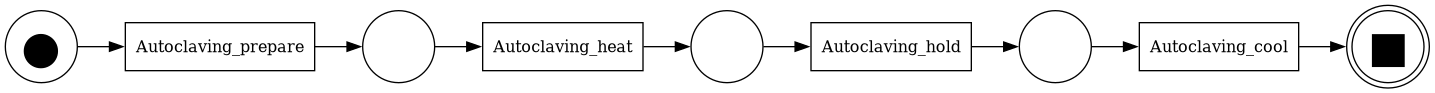


  ALGORITHM: ALPHA

Processing: autoclaving (sterilization_line) - Autoclaving
  Mining algorithm: alpha
  Found 4 unique activities: ['Autoclaving_prepare' 'Autoclaving_heat' 'Autoclaving_hold'
 'Autoclaving_cool']
    Autoclaving_prepare: best fit = norm (1.998676705638474, 0.039622277726927856)
    Autoclaving_heat: best fit = weibull_min (8.508917704463343, 0.0, 17.589882003885933)
    Autoclaving_hold: best fit = weibull_min (7.270323678472697, 0.0, 13.612509314839542)
    Autoclaving_cool: best fit = weibull_min (8.063219497778288, 0.0, 27.276186709011345)
    Mining Petri net with 'alpha' (candidate 1/1): noise=0.2, heur={}


replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9842, fitness=1.0000, precision=1.0000, generalization=0.9367544467966324, simplicity=1.0
    Selected params: noise=0.2, heur={} (score=0.9842)
    Petri net: 5 places, 4 transitions, 8 arcs
    Stochastic map: 4 transition weights
    Decision-point weights: 4 decision points, 0 with __END__ probability
    Max case length in training: 4
      Autoclaving_prepare: Start=True, End=False, Transitions={'Autoclaving_heat': 1.0}
      Autoclaving_heat: Start=False, End=False, Transitions={'Autoclaving_hold': 1.0}
      Autoclaving_hold: Start=False, End=False, Transitions={'Autoclaving_cool': 1.0}
      Autoclaving_cool: Start=False, End=True, Transitions={'__END__': 1.0}
    History weights: 4 bigram keys, 4 activity-count keys

Processing: bottling (sterilization_line) - Bottling
  Mining algorithm: alpha
  Found 3 unique activities: ['Bottling_prepare' 'Bottling_working' 'Bottling_cool']
    Bottling_prepare: best fit = weibull_min (3.297853069533603, 0.0, 0.1106

replaying log with TBR, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]

      quality: score=0.9842, fitness=1.0000, precision=1.0000, generalization=0.9367544467966324, simplicity=1.0
    Selected params: noise=0.2, heur={} (score=0.9842)
    Petri net: 4 places, 3 transitions, 6 arcs
    Stochastic map: 3 transition weights
    Decision-point weights: 3 decision points, 0 with __END__ probability
    Max case length in training: 3
      Bottling_prepare: Start=True, End=False, Transitions={'Bottling_working': 1.0}
      Bottling_working: Start=False, End=False, Transitions={'Bottling_cool': 1.0}
      Bottling_cool: Start=False, End=True, Transitions={'__END__': 1.0}
    History weights: 3 bigram keys, 3 activity-count keys

Processing: destillation (sterilization_line) - Destillation
  Mining algorithm: alpha
  Found 1 unique activities: ['Destillation_heat']
    Destillation_heat: best fit = weibull_min (3.2903830188083383, 0.0, 0.663379508518636)
    Mining Petri net with 'alpha' (candidate 1/1): noise=0.2, heur={}
      quality: score=0.9842, fitness

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]


  Per-station conformance (6 stations):
    TRAIN  fitness=1.0000  precision=1.0000  generalization=0.9368  simplicity=1.0000
    TEST   fitness=1.0000  precision=1.0000  generalization=0.9368  simplicity=1.0000
[DEBUG __init__] mode=petri_net, process_models is None: False, process_models len: 6
Building config from 14 activities:
  Config: ('Autoclaving_prepare', 'autoclaving', 'sterilization_line', 'Autoclaving')
    Transitions: {'Autoclaving_heat': 1.0}
    Start: True
  Config: ('Autoclaving_heat', 'autoclaving', 'sterilization_line', 'Autoclaving')
    Transitions: {'Autoclaving_hold': 1.0}
    Start: False
  Config: ('Autoclaving_hold', 'autoclaving', 'sterilization_line', 'Autoclaving')
    Transitions: {'Autoclaving_cool': 1.0}
    Start: False
  Config: ('Autoclaving_cool', 'autoclaving', 'sterilization_line', 'Autoclaving')
    Transitions: {'__END__': 1.0}
    Start: False
  Config: ('Bottling_prepare', 'bottling', 'sterilization_line', 'Bottling')
    Transitions: {'Bott

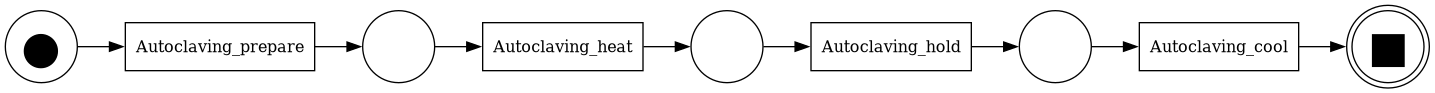

In [34]:
from IPython.display import Image, display as ipy_display
from pm4py.visualization.petri_net import visualizer as pn_vis

log_train = to_pm4py_log(df_train)
log_test  = to_pm4py_log(df_test)

ALGORITHMS = ['inductive', 'heuristic', 'alpha']
results = []

def _compute_event_ratio(sim_log_df, real_log_df):
    return float(len(sim_log_df) / len(real_log_df)) if len(real_log_df) > 0 else np.nan

def _compute_duration_errors(sim_log_df, real_log_df):
    s = (sim_log_df['timestamp_end'] - sim_log_df['timestamp_start']).dt.total_seconds().dropna()
    r = (real_log_df['timestamp_end'] - real_log_df['timestamp_start']).dt.total_seconds().dropna()
    if len(s) == 0 or len(r) == 0:
        return np.nan, np.nan
    mean_err   = abs(s.mean()   - r.mean())   / r.mean()   if r.mean()   != 0 else np.nan
    median_err = abs(s.median() - r.median()) / r.median() if r.median() != 0 else np.nan
    return float(mean_err), float(median_err)

def _run_simulation(stats_df, pp, process_models):
    sim = ProcessSimulation(activity_stats_df=stats_df, production_plan=pp,
                            mode="petri_net", process_models=process_models)
    return sim.run()

for algo in ALGORITHMS:
    print(f"\n{chr(61)*60}")
    print(f"  ALGORITHM: {algo.upper()}")
    print(f"{chr(61)*60}")

    stats_df, raw_df, process_models = extract_process(df_train, mining_algorithm=algo)

    # per-station conformance (each net vs its own station log)
    fit_tr_list, prec_tr_list, gen_list, sim_list = [], [], [], []
    fit_te_list, prec_te_list = [], []
    seen_stations = set()
    for key, pm_entry in (process_models or {}).items():
        obj, obj_type, station = key
        if (obj_type, station) in seen_stations:
            continue
        seen_stations.add((obj_type, station))
        net_s, im_s, fm_s = pm_entry["net"], pm_entry["im"], pm_entry["fm"]
        df_tr_st  = df_train[df_train["higher_level_activity"] == station].copy()
        df_te_st  = df_test [df_test ["higher_level_activity"] == station].copy()
        log_tr_st = to_pm4py_log(df_tr_st)
        log_te_st = to_pm4py_log(df_te_st)
        fit_tr_list.append(_fitness(log_tr_st, net_s, im_s, fm_s))
        prec_tr_list.append(_precision(log_tr_st, net_s, im_s, fm_s))
        fit_te_list.append(_fitness(log_te_st, net_s, im_s, fm_s))
        prec_te_list.append(_precision(log_te_st, net_s, im_s, fm_s))
        gen_list.append(_generalization(log_tr_st, net_s, im_s, fm_s))
        sim_list.append(_simplicity(net_s))

    fit_tr  = float(np.nanmean(fit_tr_list))
    prec_tr = float(np.nanmean(prec_tr_list))
    fit_te  = float(np.nanmean(fit_te_list))
    prec_te = float(np.nanmean(prec_te_list))
    gen_val = float(np.nanmean(gen_list))
    sim_val = float(np.nanmean(sim_list))

    print(f"\n  Per-station conformance ({len(seen_stations)} stations):")
    print(f"    TRAIN  fitness={fit_tr:.4f}  precision={prec_tr:.4f}  generalization={gen_val:.4f}  simplicity={sim_val:.4f}")
    print(f"    TEST   fitness={fit_te:.4f}  precision={prec_te:.4f}  generalization={gen_val:.4f}  simplicity={sim_val:.4f}")

    # simulation on TRAIN
    pp_train = df_production_plan[df_production_plan["case_id"].isin(_train_cases)].copy()
    if pp_train.empty:
        pp_train = df_production_plan.copy()
    try:
        sim_log_tr = _run_simulation(stats_df, pp_train, process_models)
        evt_ratio_tr = _compute_event_ratio(sim_log_tr, df_train)
        mean_dur_tr, med_dur_tr = _compute_duration_errors(sim_log_tr, df_train)
        print(f"\n  Simulation vs TRAIN: evt_ratio={evt_ratio_tr:.3f}  mean_dur_err={mean_dur_tr:.4f}  med_dur_err={med_dur_tr:.4f}")
    except Exception as e:
        print(f"  [TRAIN SIM] failed: {e}")
        evt_ratio_tr = mean_dur_tr = med_dur_tr = np.nan

    # simulation on TEST
    pp_test = df_production_plan[df_production_plan["case_id"].isin(_test_cases)].copy()
    if pp_test.empty:
        pp_test = df_production_plan.copy()
    try:
        sim_log_te = _run_simulation(stats_df, pp_test, process_models)
        evt_ratio_te = _compute_event_ratio(sim_log_te, df_test)
        mean_dur_te, med_dur_te = _compute_duration_errors(sim_log_te, df_test)
        print(f"  Simulation vs TEST:  evt_ratio={evt_ratio_te:.3f}  mean_dur_err={mean_dur_te:.4f}  med_dur_err={med_dur_te:.4f}")
    except Exception as e:
        print(f"  [TEST SIM] failed: {e}")
        evt_ratio_te = mean_dur_te = med_dur_te = np.nan

    results.append({
        "algo": algo,
        "train_fitness": fit_tr, "train_precision": prec_tr,
        "train_generalization": gen_val, "train_simplicity": sim_val,
        "train_evtratio": evt_ratio_tr, "train_meandurerr": mean_dur_tr, "train_meddurerr": med_dur_tr,
        "test_fitness": fit_te, "test_precision": prec_te,
        "test_generalization": gen_val, "test_simplicity": sim_val,
        "test_evtratio": evt_ratio_te, "test_meandurerr": mean_dur_te, "test_meddurerr": med_dur_te,
    })

    # visualise first Petri net
    try:
        first_key = next(iter(process_models or {}))
        pm_vis    = process_models[first_key]
        gviz = pn_vis.apply(pm_vis["net"], pm_vis["im"], pm_vis["fm"],
                            variant=pn_vis.Variants.FREQUENCY,
                            parameters={"log": log_train})
        with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
            pn_vis.save(gviz, f.name)
            obj_v, _, sta_v = first_key
            print(f"\n    Petri net ({algo} / {obj_v} - {sta_v}):")
            ipy_display(Image(filename=f.name))
    except Exception as e:
        print(f"    (visualisation failed: {e})")

,algo,train_fitness,train_precision,train_generalization,train_simplicity,train_evtratio,train_meandurerr,train_meddurerr,test_fitness,test_precision,test_generalization,test_simplicity,test_evtratio,test_meandurerr,test_meddurerr
0,inductive,1.0,1.0,0.9368,1.0,1.0,0.0173,0.0348,1.0,1.0,0.9368,1.0,1.0,0.0507,0.2442
1,heuristic,1.0,1.0,0.9368,1.0,1.0,0.0173,0.0348,1.0,1.0,0.9368,1.0,1.0,0.0507,0.2442
2,alpha,1.0,1.0,0.9368,1.0,1.0,0.0173,0.0348,1.0,1.0,0.9368,1.0,1.0,0.0507,0.2442


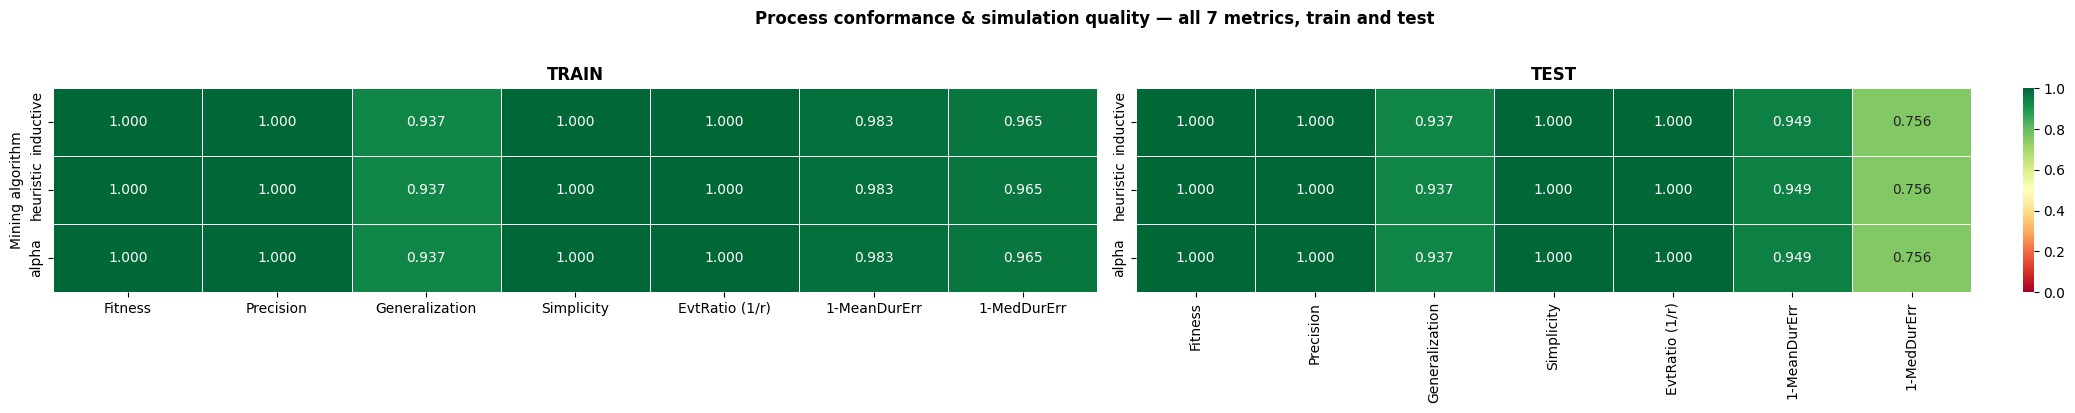


Note: Generalization is a property of the net+training log; the same value appears in both splits.
Note: EvtRatio >1 (shown inverted) is expected (~2.14x) because the sim runs each batch through ALL resource objects.


In [35]:
res_df = pd.DataFrame(results)
display(res_df.round(4))

if not res_df.empty:
    COLS = ["fitness", "precision", "generalization", "simplicity", "evtratio", "meandurerr", "meddurerr"]

    train_raw = res_df.set_index("algo")[[f"train_{c}" for c in COLS]].copy()
    test_raw  = res_df.set_index("algo")[[f"test_{c}"  for c in COLS]].copy()

    # invert so that higher=better for all columns in the heatmap
    for df_ in (train_raw, test_raw):
        for c in ("evtratio",):
            col = [x for x in df_.columns if x.endswith(c)][0]
            df_[col] = (1.0 / df_[col].replace(0, np.nan)).clip(0, 1)
        for c in ("meandurerr", "meddurerr"):
            col = [x for x in df_.columns if x.endswith(c)][0]
            df_[col] = (1.0 - df_[col]).clip(0, 1)

    labels = ["Fitness", "Precision", "Generalization", "Simplicity",
              "EvtRatio (1/r)", "1-MeanDurErr", "1-MedDurErr"]
    train_raw.columns = labels
    test_raw.columns  = labels

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 4))

    sns.heatmap(train_raw.round(3), annot=True, fmt=".3f", cmap="RdYlGn",
                vmin=0, vmax=1, linewidths=0.5, cbar=False, ax=ax1)
    ax1.set_title("TRAIN", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Mining algorithm")

    sns.heatmap(test_raw.round(3), annot=True, fmt=".3f", cmap="RdYlGn",
                vmin=0, vmax=1, linewidths=0.5, ax=ax2)
    ax2.set_title("TEST", fontsize=12, fontweight="bold")
    ax2.set_ylabel("")

    plt.suptitle("Process conformance & simulation quality — all 7 metrics, train and test",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    print("\nNote: Generalization is a property of the net+training log; the same value appears in both splits.")
    print("Note: EvtRatio >1 (shown inverted) is expected (~2.14x) because the sim runs each batch through ALL resource objects.")